##**Inverse Kinematics of a 3DOF Robot: Machine Learning Approach**






In [70]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Part 1: Robot Class and Forward Kinematics


The `RobotKinematics` class handles the forward kinematics of a 3DOF (3-degree-of-freedom) robotic arm. It calculates the end-effector position (x, y) and orientation (phi) from given joint angles (theta1, theta2, theta3). The class also includes methods to generate training data with stratified sampling to ensure diverse coverage of the joint angle space. The `_is_reachable` method checks whether a given position is within the robot's workspace, ensuring only valid configurations are included in the dataset. This class is essential for creating the training data needed to train the inverse kinematics model.

In [71]:
class RobotKinematics:

    def __init__(self, links_length=[0.17,0.19,0.23]):
        self.links_length = np.array(links_length)
        self.total_length = sum(links_length)

    def forward_kinematics(self, theta):
        #Compute end-effector position from joint angles
        theta = np.array(theta)
        x = self.links_length[0] * np.cos(theta[0]) + self.links_length[1] * np.cos(theta[0] + theta[1]) + self.links_length[2] * np.cos(theta[0] + theta[1] + theta[2])
        y = self.links_length[0] * np.sin(theta[0]) + self.links_length[1] * np.sin(theta[0] + theta[1]) + self.links_length[2] * np.sin(theta[0] + theta[1] + theta[2])
        phi = (theta[0] + theta[1] + theta[2]) % (2 * np.pi)
        return np.array([x, y, phi])

    def generate_training_data(self, num_samples=50000):


        theta1 = np.concatenate([
            np.random.uniform(-np.pi, -np.pi/2, num_samples//4),
            np.random.uniform(-np.pi/2, 0, num_samples//4),
            np.random.uniform(0, np.pi/2, num_samples//4),
            np.random.uniform(np.pi/2, np.pi, num_samples//4)
        ])

        theta2 = np.concatenate([
            np.random.uniform(-np.pi, -np.pi/2, num_samples//4),
            np.random.uniform(-np.pi/2, 0, num_samples//4),
            np.random.uniform(0, np.pi/2, num_samples//4),
            np.random.uniform(np.pi/2, np.pi, num_samples//4)
        ])


        theta3 = np.concatenate([
            np.random.uniform(-np.pi, -np.pi/2, num_samples//4),
            np.random.uniform(-np.pi/2, 0, num_samples//4),
            np.random.uniform(0, np.pi/2, num_samples//4),
            np.random.uniform(np.pi/2, np.pi, num_samples//4)
        ])

        data = []
        for t1, t2, t3 in zip(theta1, theta2, theta3):
            x, y, phi = self.forward_kinematics([t1, t2, t3])
            if self._is_reachable(x, y):
                data.append([x, y, phi, t1, t2, t3])

        return np.array(data)

    def _is_reachable(self, x, y):
        #Check if position is within workspace
        r = np.sqrt(x**2 + y**2)
        return r <= self.total_length and r >= abs(self.links_length[0] - self.links_length[1] - self.links_length[2])

### Part 2: AngleNormalizer and PositionNormalizer Classes
The `AngleNormalizer` class provides static methods to normalize and denormalize joint angles, scaling them to the range [-1, 1] for training and converting them back to radians for evaluation. The `PositionNormalizer` class normalizes the end-effector positions and orientations using mean and standard deviation, ensuring consistent input scales for the neural network. These normalization steps are critical for stable and efficient training, as they prevent large input ranges from skewing the model's learning process.

In [72]:
class AngleNormalizer:

    @staticmethod
    def normalize(angles):
        return angles / np.pi

    @staticmethod
    def denormalize(norm_angles):
        angles = norm_angles * np.pi
        return (angles + np.pi) % (2 * np.pi) - np.pi  # Wrap to [-π, π]

In [73]:
class PositionNormalizer:

    def __init__(self, data):
        self.x_mean, self.y_mean = np.mean(data[:, :2], axis=0)
        self.x_std, self.y_std = np.std(data[:, :2], axis=0)
        self.phi_mean, self.phi_std = np.mean(data[:, 2]), np.std(data[:, 2])

    def normalize(self, positions):
        norm_pos = np.empty_like(positions)
        norm_pos[:, 0] = (positions[:, 0] - self.x_mean) / self.x_std
        norm_pos[:, 1] = (positions[:, 1] - self.y_mean) / self.y_std
        norm_pos[:, 2] = (positions[:, 2] - self.phi_mean) / self.phi_std
        return norm_pos

    def denormalize(self, norm_pos):
        positions = np.empty_like(norm_pos)
        positions[:, 0] = norm_pos[:, 0] * self.x_std + self.x_mean
        positions[:, 1] = norm_pos[:, 1] * self.y_std + self.y_mean
        positions[:, 2] = norm_pos[:, 2] * self.phi_std + self.phi_mean
        return positions

### Part 3: Multi-Layer Perceptron (MLP) Model
The `IK_MLP` class defines a neural network for solving the inverse kinematics problem. It consists of four fully connected layers with batch normalization, dropout for regularization, and SiLU activation functions. The network includes a residual connection to improve gradient flow and uses a `tanh` activation in the output layer to constrain predictions to the [-1, 1] range. This architecture is designed to handle the nonlinear relationship between end-effector positions and joint angles effectively.

In [74]:
class IK_MLP(nn.Module):

    def __init__(self, input_size=3, output_size=3):
        super(IK_MLP, self).__init__()

        # First layer
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)

        # Second layer with matching dimensions for residual
        self.fc2 = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)

        # Third layer
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)

        # Output layer
        self.fc4 = nn.Linear(256, output_size)

        self.dropout = nn.Dropout(0.3)
        self.activation = nn.SiLU()

    def forward(self, x):
        # First block
        x = self.activation(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        # Second block with residual connection
        residual = x
        x = self.activation(self.bn2(self.fc2(x)))
        x = self.dropout(x + residual)  # Now dimensions match

        # Third block
        x = self.activation(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        # Output
        x = self.fc4(x)

        return torch.tanh(x)  # Constrain outputs to [-1, 1] range

### Part 4: Trainer Class

The `Trainer` class manages the training and evaluation of the `IK_MLP` model. It includes a custom angular loss function to account for the periodic nature of joint angles and uses the AdamW optimizer with cosine annealing learning rate scheduling. The class tracks training and validation losses, saves the best model, and provides methods for evaluating performance. This ensures the model is trained efficiently and generalizes well to unseen data.

In [75]:
class Trainer:

    def __init__(self, model, pos_normalizer):
        self.model = model
        self.pos_normalizer = pos_normalizer
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def angular_loss(self, pred, target):
        #Custom loss function for angular regression
        diff = pred - target
        return torch.mean(torch.atan2(torch.sin(diff), torch.cos(diff))**2)

    def train(self, train_loader, val_loader, epochs=500, lr=0.001):
        optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        best_loss = float('inf')
        train_losses = []
        val_losses = []

        for epoch in tqdm(range(epochs), desc="Training"):
            # Training phase
            self.model.train()
            epoch_train_loss = 0
            for batch in train_loader:
                inputs, targets = batch
                inputs, targets = inputs.to(self.device), targets.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.angular_loss(outputs, targets)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()

            train_losses.append(epoch_train_loss / len(train_loader))

            # Validation phase
            val_loss = self.evaluate(val_loader)
            val_losses.append(val_loss)

            # Update learning rate
            scheduler.step()

            # Save best model
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(self.model.state_dict(), "best_ik_model.pth")

        return train_losses, val_losses

    def evaluate(self, data_loader):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in data_loader:
                inputs, targets = batch
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                total_loss += self.angular_loss(outputs, targets).item()

        return total_loss / len(data_loader)

    def plot_losses(self, train_losses, val_losses):
        #Plot training and validation curves
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid(True)
        plt.show()

### Part 5: Data Preparation and Analysis Functions

The `prepare_data` function splits the dataset into training, validation, and test sets, normalizes the data, and creates PyTorch DataLoader objects for efficient batch processing. The `analyze_results` function evaluates the model's performance by comparing predicted and true joint angles, calculating position and orientation errors. These functions streamline the workflow and provide insights into the model's accuracy.


In [76]:
def prepare_data(data, pos_normalizer, batch_size=64):

    # Split into features (positions) and targets (angles)
    X = data[:, :3]  # x, y, phi
    y = data[:, 3:]   # theta1, theta2, theta3

    # Normalize data
    X_norm = pos_normalizer.normalize(X)
    y_norm = AngleNormalizer.normalize(y)

    # Split into train/val/test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_norm, y_norm, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42)

    # Create datasets and loaders
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(
        torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    test_dataset = TensorDataset(
        torch.FloatTensor(X_test), torch.FloatTensor(y_test))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [77]:
def analyze_results(robot, model, pos_normalizer, test_loader):

    model.eval()
    errors = []

    with torch.no_grad():
        for batch in test_loader:
            inputs, targets = batch
            outputs = model(inputs)

            # Denormalize predictions and targets
            pred_angles = AngleNormalizer.denormalize(outputs.numpy())
            true_angles = AngleNormalizer.denormalize(targets.numpy())
            positions = pos_normalizer.denormalize(inputs.numpy())

            # Calculate forward kinematics for both
            for i in range(len(pred_angles)):
                pred_pos = robot.forward_kinematics(pred_angles[i])
                true_pos = robot.forward_kinematics(true_angles[i])

                # Position error
                pos_error = np.linalg.norm(pred_pos[:2] - true_pos[:2])

                # Angle error (considering periodicity)
                angle_error = abs((pred_pos[2] - true_pos[2] + np.pi) % (2*np.pi) - np.pi)

                errors.append([pos_error, angle_error])

    errors = np.array(errors)
    print(f"Mean Position Error: {np.mean(errors[:, 0]):.4f} units")
    print(f"Mean Angle Error: {np.degrees(np.mean(errors[:, 1])):.4f} degrees")

    return errors

### Part 6: Plotting and Trajectory Comparison
The `plot_trajectory_comparison` function visualizes the model's predictions against an analytical trajectory, demonstrating how well the learned inverse kinematics approximates the true solution. This is useful for qualitative assessment of the model's performance. The `plot_losses` method in the `Trainer` class plots training and validation loss curves, helping to monitor convergence and detect overfitting.

In [78]:
def plot_trajectory_comparison(robot, model, pos_normalizer):
    """Compare analytical and predicted trajectories"""
    # Generate test trajectory
    t = np.linspace(0, 10, 101)

    #Analytical solution equations

    theta1_analytical = (np.pi/4) + (np.pi/9) * np.sin((np.pi/5) * t)
    theta2_analytical = (np.pi/4) + (np.pi/9) * np.sin((np.pi/5) * t)
    theta3_analytical = (np.pi/4) + (np.pi/9) * np.sin((np.pi/5) * t)

    # Compute forward kinematics for analytical solution
    x_analytical, y_analytical, phi_analytical = [], [], []
    for t1, t2, t3 in zip(theta1_analytical, theta2_analytical, theta3_analytical):
        x, y, phi = robot.forward_kinematics([t1, t2, t3])
        x_analytical.append(x)
        y_analytical.append(y)
        phi_analytical.append(phi)

    # Prepare input for model
    X_test = np.column_stack((x_analytical, y_analytical, phi_analytical))
    X_test_norm = pos_normalizer.normalize(X_test)
    X_test_tensor = torch.FloatTensor(X_test_norm)

    # Get model predictions
    model.eval()
    with torch.no_grad():
        y_pred_norm = model(X_test_tensor).numpy()

    theta_pred = AngleNormalizer.denormalize(y_pred_norm)

    # Plot comparison
    plt.figure(figsize=(15, 10))

    # Plot theta1
    plt.subplot(3, 1, 1)
    plt.plot(t, theta1_analytical, label='Analytical θ1', linewidth=2)
    plt.plot(t, theta_pred[:, 0], '--', label='Predicted θ1', linewidth=2)
    plt.ylabel('θ1 (rad)')
    plt.legend()
    plt.grid(True)

    # Plot theta2
    plt.subplot(3, 1, 2)
    plt.plot(t, theta2_analytical, label='Analytical θ2', linewidth=2)
    plt.plot(t, theta_pred[:, 1], '--', label='Predicted θ2', linewidth=2)
    plt.ylabel('θ2 (rad)')
    plt.legend()
    plt.grid(True)

    # Plot theta3
    plt.subplot(3, 1, 3)
    plt.plot(t, theta3_analytical, label='Analytical θ3', linewidth=2)
    plt.plot(t, theta_pred[:, 2], '--', label='Predicted θ3', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('θ3 (rad)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Part 7: Main Function
The `main` function orchestrates the entire workflow: generating training data, initializing normalizers, preparing data loaders, training the model, and evaluating its performance. It also visualizes results and saves the best model. This function serves as the entry point for running the inverse kinematics learning pipeline, ensuring all steps are executed in the correct order.

Training: 100%|██████████| 400/400 [00:36<00:00, 10.81it/s]


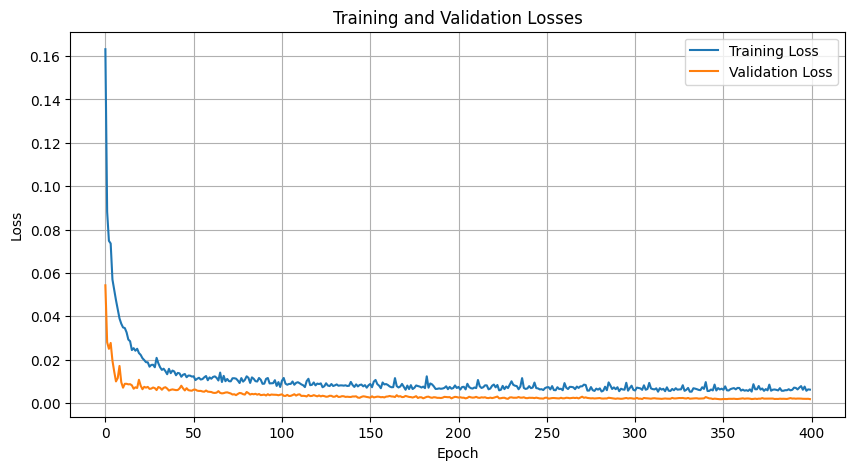

Final Test Loss: 0.0017
Mean Position Error: 0.0248 units
Mean Angle Error: 3.1973 degrees


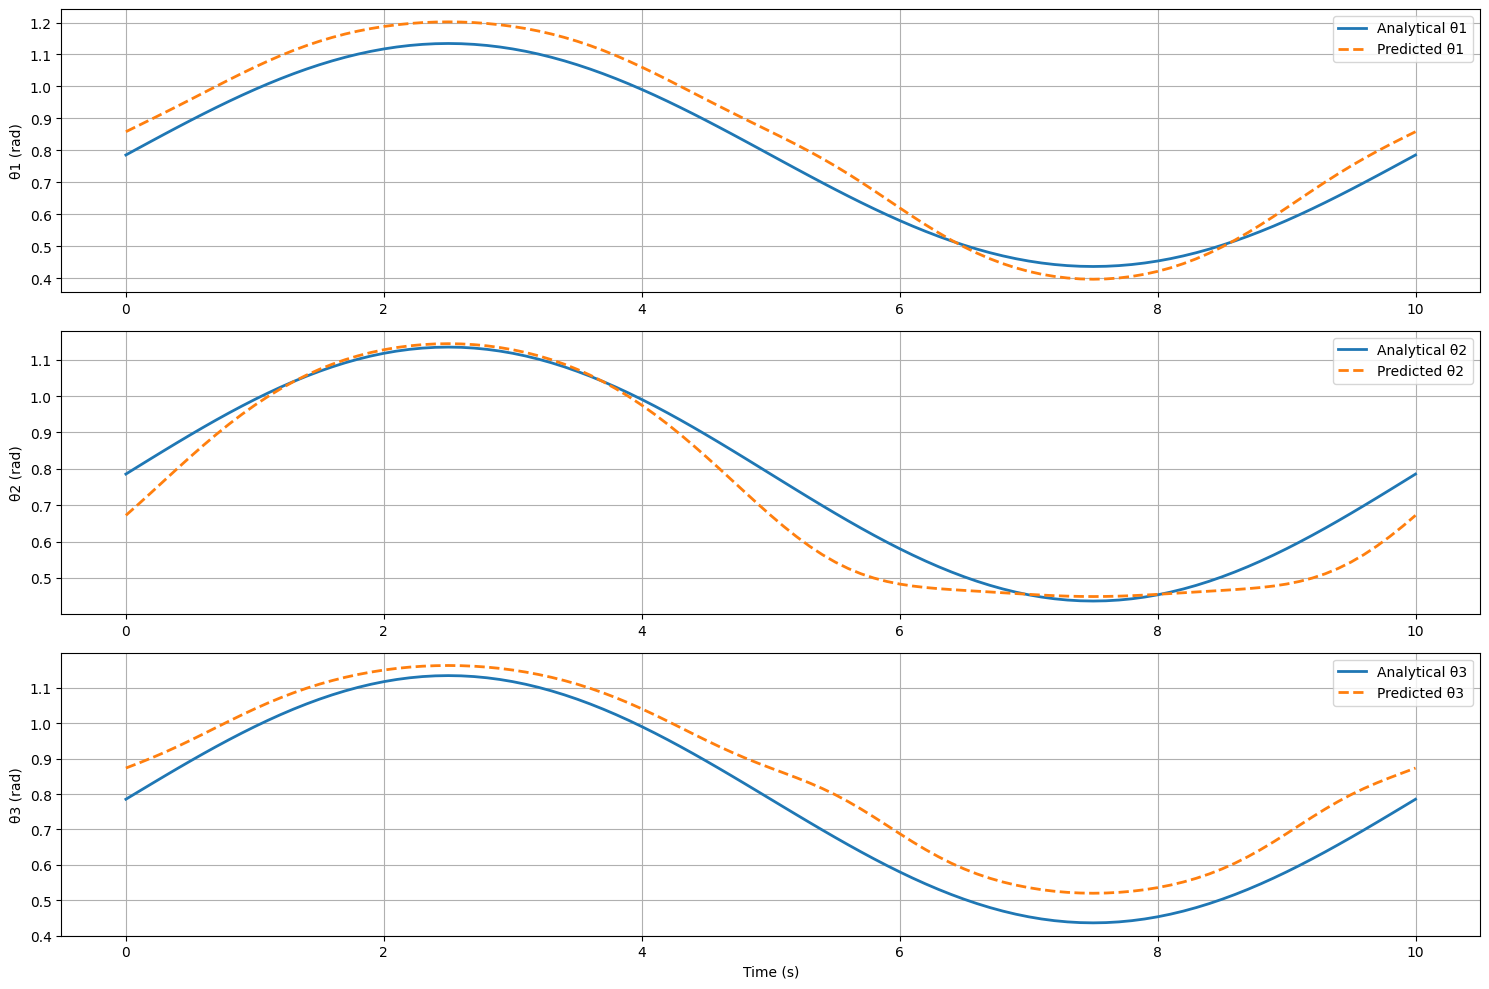

In [69]:
def main():
    # Initialize robot and generate training data
    robot = RobotKinematics()
    data = robot.generate_training_data(num_samples=1000)

    # Initialize normalizers
    pos_normalizer = PositionNormalizer(data[:, :3])

    # Prepare data loaders
    train_loader, val_loader, test_loader = prepare_data(data, pos_normalizer)

    # Initialize model and trainer
    model = IK_MLP()
    trainer = Trainer(model, pos_normalizer)

    # Train model
    train_losses, val_losses = trainer.train(train_loader, val_loader, epochs=400)
    trainer.plot_losses(train_losses, val_losses)

    # Load best model
    model.load_state_dict(torch.load("best_ik_model.pth"))

    # Evaluate on test set
    test_loss = trainer.evaluate(test_loader)
    print(f"Final Test Loss: {test_loss:.4f}")

    # Analyze errors
    errors = analyze_results(robot, model, pos_normalizer, test_loader)

    # Plot trajectory comparison
    plot_trajectory_comparison(robot, model, pos_normalizer)

if __name__ == "__main__":
    main()